In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, skewnorm

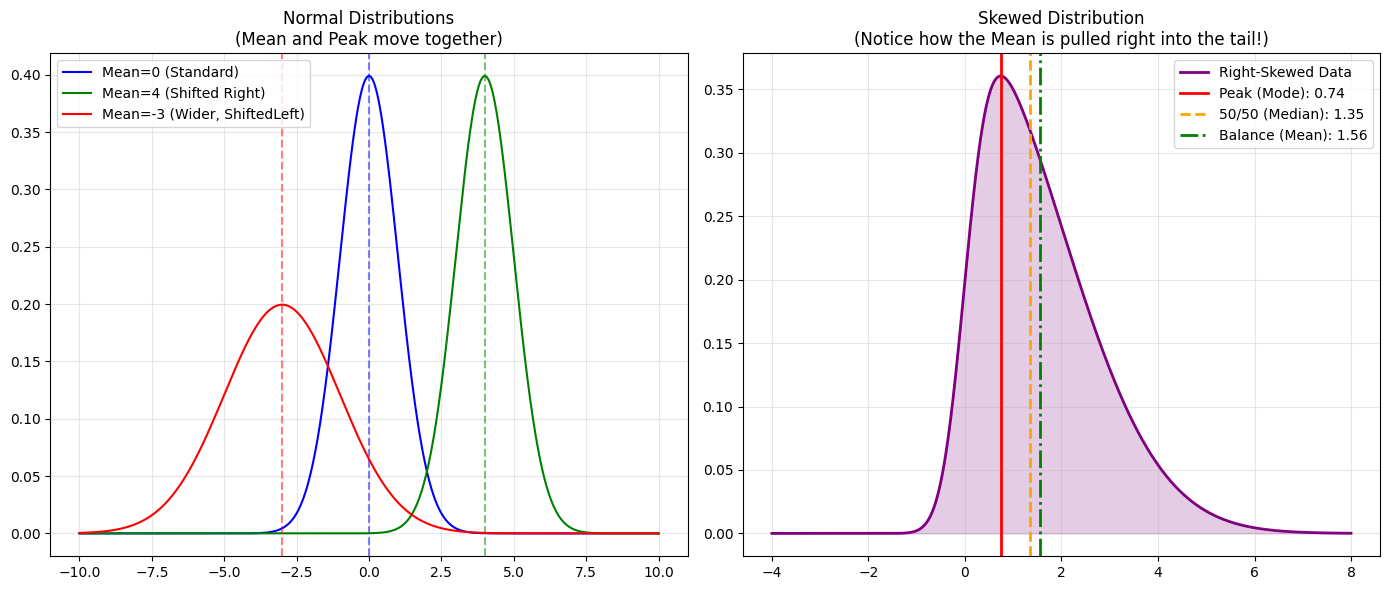

In [5]:
# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================
# GRAPH 1: True Normal Distributions
# ==========================================
x_normal = np.linspace(-10, 10, 1000)

# 1. Standard Normal (Mean = 0, Std Dev = 1)
y1 = norm.pdf(x_normal, loc=0, scale=1)
ax1.plot(x_normal, y1, label="Mean=0 (Standard)", color='blue')
ax1.axvline(0, color='blue', linestyle='--', alpha=0.5)

# 2. Shifted Right (Mean = 4, Std Dev = 1)
y2 = norm.pdf(x_normal, loc=4, scale=1)
ax1.plot(x_normal, y2, label="Mean=4 (Shifted Right)", color='green')
ax1.axvline(4, color='green', linestyle='--', alpha=0.5)

# 3. Wider & Shifted Left (Mean = -3, Std Dev = 2)
y3 = norm.pdf(x_normal, loc=-3, scale=2)
ax1.plot(x_normal, y3, label="Mean=-3 (Wider, ShiftedLeft)", color='red')
ax1.axvline(-3, color='red', linestyle='--', alpha=0.5)

ax1.set_title("Normal Distributions\n(Mean and Peak move together)")
ax1.legend()
ax1.grid(True, alpha=0.3)
# ==========================================
# GRAPH 2: Skewed Distributions
# ==========================================
x_skew = np.linspace(-4, 8, 1000)

# Create a right-skewed distribution (tail stretches right)
skewness_factor = 5
y_skew = skewnorm.pdf(x_skew, skewness_factor, loc=0, scale=2)

ax2.plot(x_skew, y_skew, label="Right-Skewed Data", color='purple', linewidth=2)
ax2.fill_between(x_skew, y_skew, alpha=0.2, color='purple')

# Calculate the actual Mean, Median, and Mode for the skewed data
# Scipy skewnorm stats returns mean. Median is ppf(0.5). Mode is the peak of the PDF.
mean_val = skewnorm.stats(skewness_factor, loc=0, scale=2, moments='m')
median_val = skewnorm.ppf(0.5, skewness_factor, loc=0, scale=2)
mode_val = x_skew[np.argmax(y_skew)]

# Draw the lines to show how they separate!
ax2.axvline(mode_val, color='red', linestyle='-', linewidth=2, label=f'Peak (Mode): {mode_val:.2f}')
ax2.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'50/50 (Median): {median_val:.2f}')
ax2.axvline(mean_val, color='green', linestyle='-.', linewidth=2, label=f'Balance (Mean): {mean_val:.2f}')

ax2.set_title("Skewed Distribution\n(Notice how the Mean is pulled right into the tail!)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Show the plots
plt.tight_layout()
plt.show()